In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# settings
plt.rcParams['figure.figsize'] = [10, 5]

In [2]:
# import numerical integration
from scipy.integrate import cumulative_trapezoid
# import own python functions
%run py-functions/hemispherical_electrode.py # as example
%run py-functions/Semi-Operators.py

# Semiintegration Guide

Here we firstly introduce the mathematical understanding of the semi-operators and the link to the voltammograms. Afterwards we setup a simple steady-state voltammogram and presents some methods for the semiintegration. These methods will be then applyed on the voltammogram and compare them with a numerical integral.

These methods are (unless otherwise stated) based from Oldham: *Electrochemical Science and Technology, 2012*, including its web resources: $\texttt{Web1244}$,  $\texttt{Web1245}$. 

# Semi-Operations

The differentiation and the integration are common mathematical operations. The differentiation of an arbitrary function is often expressed by:

$$
\begin{align}
\frac{d}{dt} f(x)
\end{align}
$$

Interestingly, the integration can also be expressed in a similar way:
$$
\begin{align}
\frac{d^{-1}}{dt^{-1}} f(x) = \int_0^t f(\tau) d\tau
\end{align}
$$

Therefore we can express these operations in a more general way by:

$$
\begin{align}
\frac{d^{v}}{dt^{v}} f(x) = \int_0^t f(\tau) d\tau
\end{align}
$$

With:
* $v= 1$: Differentiation 
* $v=-1$: Integration

In order to that we introduce the so-called **semi-operators**, where for $v=1/2$ we have the seimidifferentiation and (more interestingly for us) with $v=-1/2$ the seimiintegration. The following picture explains the similarities of the operators to each other.


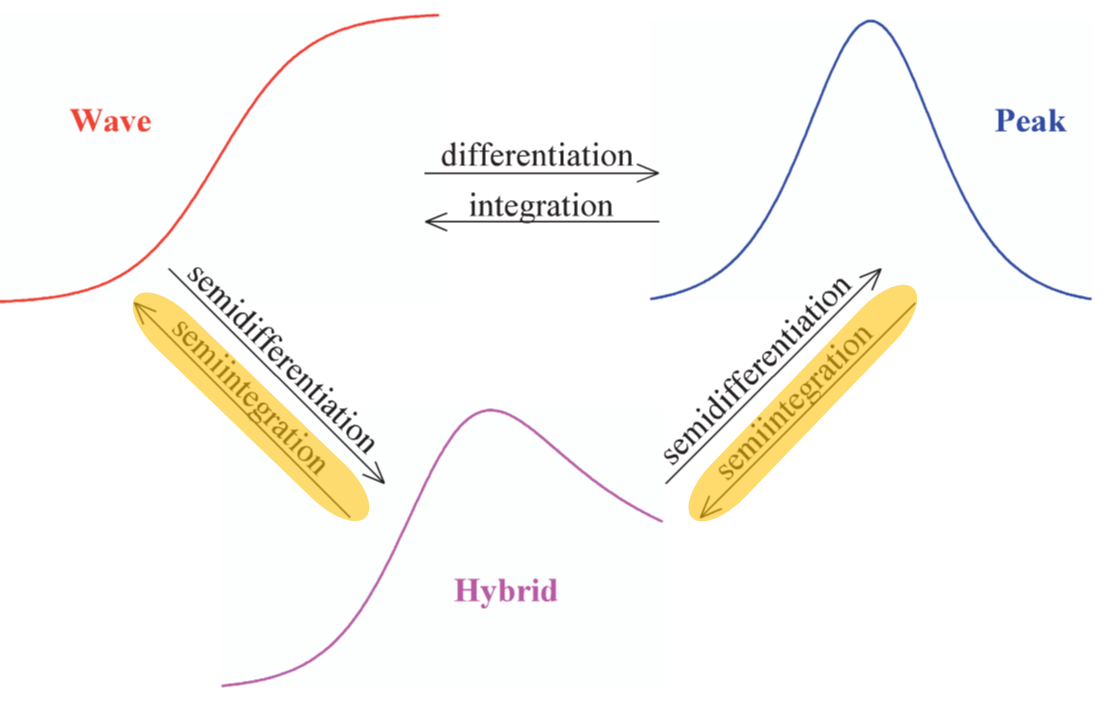

## Steady-State Voltammogram
Let's first start with an examplary steady-state voltammetry at hemispherical microelectrode (derived in Oldham, Electrochemical Science and Technology, 2012), which is defined by:
$$
\begin{align}
I(t) = \frac{2 \pi FD_RD_Oc^b_R r_{hemi}}{D_O + D_R \exp\left\{-F\left[ E(t) -E^{o'}\right]/RT\right\}}
\end{align}
$$
With:
* $D_R$: Diffusion coefficient of reduced specimen (in $m^2/s$)
* $D_O$: Diffusion coefficient of oxidized specimen (in $m^2/s$)
* $c^b_R$: bulk concentration of reduced specimen (in $mol/m^3$)
* $r_{hemi}$: radius of hemispherical electrode (in $m$)
* $E(t)$: time-dependend potential (in $V$)

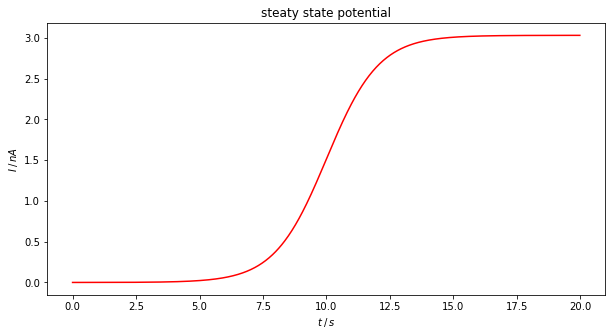

In [3]:
N_max = 1000;   # No. of time intervals

# calculate potential
[t,I] = current_hemispherical1(N_max =N_max); # with default values

# Plot the current for different scan rates
plt.plot(t,I,'r')
plt.ylabel('$I\: / \:nA$')
plt.xlabel('$t\: / \:s$')
plt.title('steaty state potential')
plt.show()

# Semiintegration methods
Now we introduce some methods to apply the semiintegration. These work in generall with discrete values, i.e. the function graph (like above) has to be seperated into discrete finite values:

$$
\begin{align}
f(0), f(\delta), ..., f((N-1)\delta), f(N\delta)
\end{align}
$$

Here we assume that the step size $\delta$ is equidistant, meaning for a fixed set of x-Values $N$:

$$
\begin{align}
\delta = \frac{x_N}{N}
\end{align}
$$


## Grünwald Algorithm
The Grünwald Algorithm can be generally expressed by taking the sum of the discrete function values multiplied with weights $w_i$ and then divided by the stepsize:

$$
\begin{align}
\frac{d^{\pm 0.5}}{dt^{\pm 0.5}} f(t) =\frac{1}{\delta^{\pm 0.5}} \sum_{n=0}^{N-1} w_n f(n\delta)
\end{align}
$$

The weight can be expressed on different ways, often the single weights $w_i$ depends on their predecessor $w_{i-1}$. As the factorial expression could lead to an overflow, this algorithm can by simplified by:


The G1 algorithms are ideal for voltammograms like linear-scan or cyclic versions, where the early signals are small.\
**Note**, that these algorithms are less suitable for step and pulse varieties, in which the initial currents are large.

### Grünwald G1 Semiintegration Algorithm

$$
\begin{align}
\frac{d^{- 0.5}}{dt^{- 0.5}} f(t) \approx \sqrt{\delta} \sum_{n=1}^{N} w_{N-n} f(n\delta)
\end{align}
$$

Which can be also displayed in reverse summation (like in the implementation):

$$
\begin{align}
\frac{d^{- 0.5}}{dt^{- 0.5}} f(t) \approx \sqrt{\delta} \sum_{n=N}^{1} w_{N-n} f(n\delta)
\end{align}
$$

With:
* $w_0 = 1$
* $w_n = \frac{(n-0.5)w_{n-1}}{n} = (1-\frac{0.5}{n})w_{n-1}$

In [4]:
def G1_Semiint1(I,t):
    # (equidistant) time step
    delta = t[1]-t[0]
    # No. of steps
    N_max = I.size
    # initialize with zeros
    G1 = np.zeros(N_max)

    sqr_d = np.sqrt(delta)
    
    for N in range(1,N_max+1):
        # value for n = N with w0 = 1
        G1_i = I[0]; 
        #      go from N to 0
        for n in range(N-1,0,-1):
            G1_i = G1_i*(1-(0.5)/n) + I[N-n]
            
        G1[N-1] = G1_i*sqr_d
    return(G1)

In [5]:
mysize = 1000
y = np.array([1]*mysize)
x = np.linspace(0,1000, mysize)

delta_x = x[1] - x[0]

d1 = G1_Semiint1(G1_Semiint1(y,x), x)
d2 = cumulative_trapezoid(y,x,initial=0)

print('      G1 values:',d1[0:4])
print('cum trap values:',d2[0:4],'\n')


print('maximum error')
error = (np.abs(d1-d2))
print('before',max(error))

# G1(N) values are equal to cum_trap(N+1)
d1_e = d1[:-1] # exclude last value
d2_e = d2[1:]  # exclude first value
x_e = x[:-1]   # exclude last value (to get same dim)
    
error = (np.abs(d1_e-d2_e))
print('after ',max(error))

np.allclose(G1_Semiint(G1_Semiint(y,x), x)[:-1], cumulative_trapezoid(y,x,initial=0)[1:], rtol=2.5e-03)

      G1 values: [1.001001 2.002002 3.003003 4.004004]
cum trap values: [0.       1.001001 2.002002 3.003003] 

maximum error
before 1.0010010010041697
after  3.183231456205249e-12


True

max error: 0.03031172565158613
mod error: 0.030308122017917327


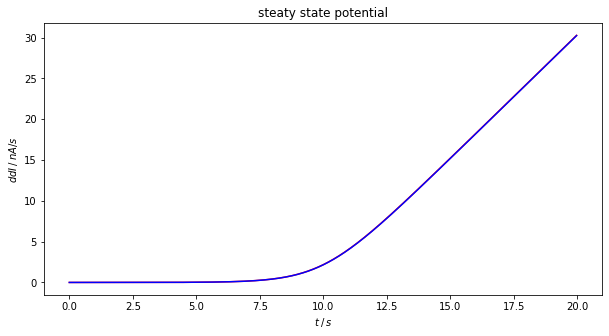

In [6]:
N_max = 1000;   # No. of time intervals

# calculate potential
[t,I] = current_hemispherical1(N_max =N_max); # with default values

# calculate double semiintegral
dI  = G1_Semiint1(I,t)
ddI = G1_Semiint1(dI,t)

# compare with numerical integration
d2 = cumulative_trapezoid(I,t,initial=0)

error = np.abs(ddI-d2)
print('max error:',max(error))

d1_e = ddI[:-1]
d2_e = d2[1:]
x_e = t[:-1]

error_e = (np.abs(d1_e-d2_e))
print('mod error:',max(error_e))

# Plot the current for different scan rates
plt.plot(t,ddI,'r')
plt.plot(t,d2,'b')
plt.ylabel('$ddI\: / \:nA/s$')
plt.xlabel('$t\: / \:s$')
plt.title('steaty state potential')
plt.show()

In [7]:
print(d1.size, d2.size)
dn1 = d1[1:]
dn2 = d2[:-1]
print(dn1.size,dn2.size)

1000 1000
999 999


### Grünwald G1 Semidifferentiation Algorithm

$$
\begin{align}
\frac{d^{0.5}}{dt^{0.5}} f(t) \approx \frac{1}{\sqrt{\delta}} \sum_{n=0}^{N-1} w_{N-n} f(n\delta)
\end{align}
$$
With:
* $w_0 = 1$
* $w_n = \frac{(n-1.5)w_{n-1}}{n}$

In [8]:
def G1_Semidiff(I,t):
    # (equidistant) time step
    delta = t[1]-t[0]
    # No. of steps
    N_max = I.size
    # initialize with zeros
    G1 = np.zeros(N_max)
    for N in range(0,N_max):
        # value for n = N with w0 = 1
        G1_i = I[0]; 
        #      go from N to 0
        for n in range(N,0,-1):
            #print(n-1)
            G1_i = G1_i*((n)-1.5)/(n) + I[N-n+1]
        G1[N] = G1_i/np.sqrt(delta)
    return(G1)

### Check the Semidifferentiation

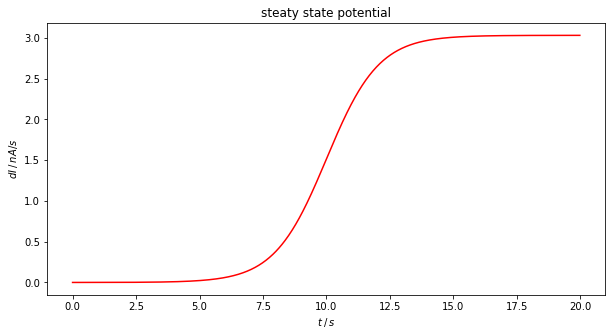

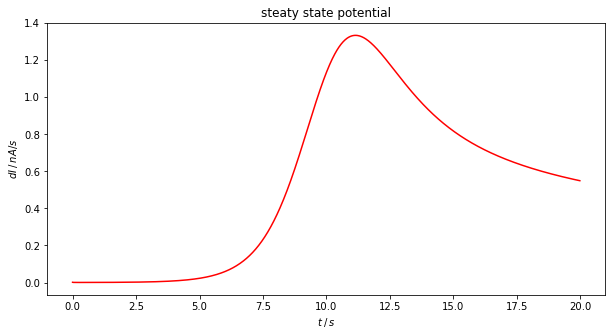

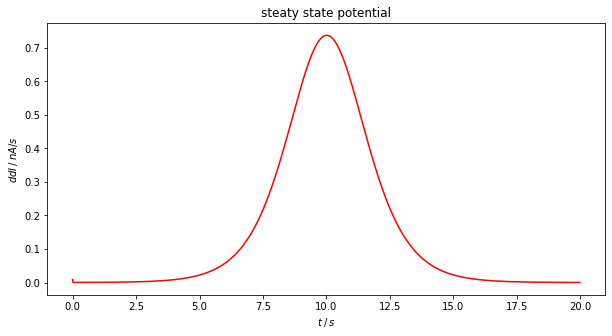

In [9]:

N_max = 1001;   # No. of time intervals

# calculate potential
[t,I] = current_hemispherical1(N_max =N_max); # with default values

dI  = G1_Semidiff(I,t)
ddI = G1_Semidiff(dI,t)

# Plot the current for different scan rates
plt.plot(t,I,'r')
plt.ylabel('$dI\: / \:nA/s$')
plt.xlabel('$t\: / \:s$')
plt.title('steaty state potential')
plt.show()

# Plot the current for different scan rates
plt.plot(t,dI,'r')
plt.ylabel('$dI\: / \:nA/s$')
plt.xlabel('$t\: / \:s$')
plt.title('steaty state potential')
plt.show()

# Plot the current for different scan rates
plt.plot(t,ddI,'r')
plt.ylabel('$ddI\: / \:nA/s$')
plt.xlabel('$t\: / \:s$')
plt.title('steaty state potential')
plt.show()